In [1]:
# Set up the file path
import os
os.chdir('..')

In [2]:
# Import packages
import numpy as np
from itertools import product
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library
from RL4CRN.rewards.deterministic import dynamic_tracking_error

In [3]:

# r1 = MassAction([], ['Z_1'], ['u_1'], [1.0])
# r2 = MassAction(['X_1'], [], ['u_2'], [1.0])
# r3 = MassAction(['Z_1'], ['X_1', 'Z_2'], [None], [16.599699020385742])
# r4 = MassAction(['X_1', 'X_1'], ['X_1'], [None], [14.140015602111816])
# r5 = MassAction(['X_1', 'Z_2'], ['X_1', 'Z_1'], [None], [19.683109283447266])
# r6 = MassAction(['Z_1', 'Z_2'], ['Z_1', 'Z_1'], [None], [26.945571899414062])
# r7 = MassAction(['Z_2', 'Z_2'], ['Z_1'], [None], [11.384536743164062])

# Zhou's secret hill-function CRN 
# r1 = MassAction([], ['X_1'], ['u_1'], [1.0])
# r2 = MassAction(['X_3'], [], [None], [1.0])
# r3 = MassAction(['X_1', 'X_3'], ['X_1', 'X_1'], [None], [28.797096252441406])
# r4 = MassAction(['X_1'], ['X_3'], [None], [28.564558029174805])
# r5 = MassAction(['X_1', 'X_2'], ['X_2'], [None], [21.710105895996094])
# r6 = MassAction(['X_2'], ['X_1', 'X_2'], [None], [25.092517852783203])
# r7 = MassAction(['X_2', 'X_3'], ['X_2', 'X_2'], [None], [22.639039993286133])

# Weird RPA CRN
# r1 = MassAction([], ['Z_1'], ['u_1'], [1.0])
# r2 = MassAction(['X_1'], [], ['u_2'], [1.0])
# r3 = MassAction(['Z_1'], ['X_1', 'Z_2'], [None], [16.49163246154785])
# r4 = MassAction(['X_1', 'X_1'], ['X_1'], [None], [16.53685188293457])
# r5 = MassAction(['X_1', 'Z_2'], [], [None], [8.820731163024902])
# r6 = MassAction(['X_1', 'Z_2'], ['Z_2', 'Z_2'], [None], [7.684998512268066])
# r7 = MassAction(['Z_1', 'Z_2'], ['Z_1', 'Z_1'], [None], [18.273298263549805])

# disturbance compression
# r1 = MassAction([], ['Z_1'], ['u_1'], [1.0])
# r2 = MassAction(['X_1'], [], ['u_2'], [1.0])
# r3 = MassAction(['Z_1'], ['X_1', 'Z_2'], [None], [10.89411449432373])
# r4 = MassAction(['X_1', 'X_1'], ['X_1'], [None], [1.3476775884628296])
# r5 = MassAction(['X_1', 'Z_2'], [], [None], [3.1511833667755127])
# r6 = MassAction(['X_1', 'Z_2'], ['Z_2'], [None], [13.062765121459961])
# r7 = MassAction(['Z_1', 'Z_2'], ['Z_1', 'Z_1'], [None], [29.677629470825195])

# classifier
reactions = []
r1 = MassAction([], ['X_1'], ['u_1'], [1.0])
r2 = MassAction([], ['X_2'], ['u_2'], [1.0])
r3 = MassAction([], ['X_3'], ['u_3'], [1.0])
r4 = MassAction(['X_1'], ['OUT', 'X_3'], [None], [3.191404104232788])
r5 = MassAction(['X_3'], ['OUT', 'X_3'], [None], [30.425180435180664])
r6 = MassAction(['X_1', 'X_1'], ['X_1', 'X_2'], [None], [16.13312339782715])
r7 = MassAction(['X_1', 'X_1'], ['OUT', 'X_3'], [None], [2.537935733795166])
r8 = MassAction(['X_1', 'X_2'], [], [None], [3.9893221855163574])
r9 = MassAction(['X_1', 'X_2'], ['X_2'], [None], [9.542977333068848])
r10 = MassAction(['OUT', 'X_3'], ['X_2', 'X_2'], [None], [5.8838958740234375])
r11 = MassAction(['OUT', 'OUT'], ['OUT', 'X_1'], [None], [3.953247547149658])
reactions.extend([r1, r2, r3, r4, r5, r6, r7, r8, r9, r10, r11])

In [6]:
# Create and compile the IOCRN
iocrn = IOCRN(reactions=reactions, output_labels=['OUT'], solver='CVODE', atol=1e-6, rtol=1e-6)
iocrn.compile()
num_inputs = iocrn.num_inputs
print(iocrn)
print("Number of inputs:", num_inputs)

Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 ----> OUT + X_3;  [MAK(3.191404104232788)]
X_3 ----> OUT + X_3;  [MAK(30.425180435180664)]
X_1 + X_1 ----> X_1 + X_2;  [MAK(16.13312339782715)]
X_1 + X_1 ----> OUT + X_3;  [MAK(2.537935733795166)]
X_1 + X_2 ----> ∅;  [MAK(3.9893221855163574)]
X_1 + X_2 ----> X_2;  [MAK(9.542977333068848)]
OUT + X_3 ----> X_2 + X_2;  [MAK(5.8838958740234375)]
OUT + OUT ----> OUT + X_1;  [MAK(3.953247547149658)]
Number of inputs: 3


In [8]:
# Construct initial conditions
ic = IC(iocrn.species_labels, values= [
    [0.0] * len(iocrn.species_labels),  # all species start at 0
])
x0_list = ic.get_ic(iocrn)
print(x0_list)

[array([0., 0., 0., 0.])]


In [11]:
# Construct inputs
# nums = [0.0, 0.5, 1.0, 1.5]
# numbs_b = [0.0, 0.5, 1.0, 1.5]
# # u_list = [np.array(u) for u in product(nums, repeat=num_inputs)] # list of input combinations, each input is a numpy array of shape (p,)
# u_list = [np.array(u) for u in product(nums, numbs_b)] # list of input combinations, each input is a numpy array of shape (p,)
# print(u_list)

# for the logic circuit
# all combination of inputs between 0 and 1 
nums = [0., 1.]
u_list = [np.array(u) for u in product(*[nums for _ in range(num_inputs)])] # list of input combinations, each input is a numpy array of shape (p,)
print(u_list)

[array([0., 0., 0.]), array([0., 0., 1.]), array([0., 1., 0.]), array([0., 1., 1.]), array([1., 0., 0.]), array([1., 0., 1.]), array([1., 1., 0.]), array([1., 1., 1.])]


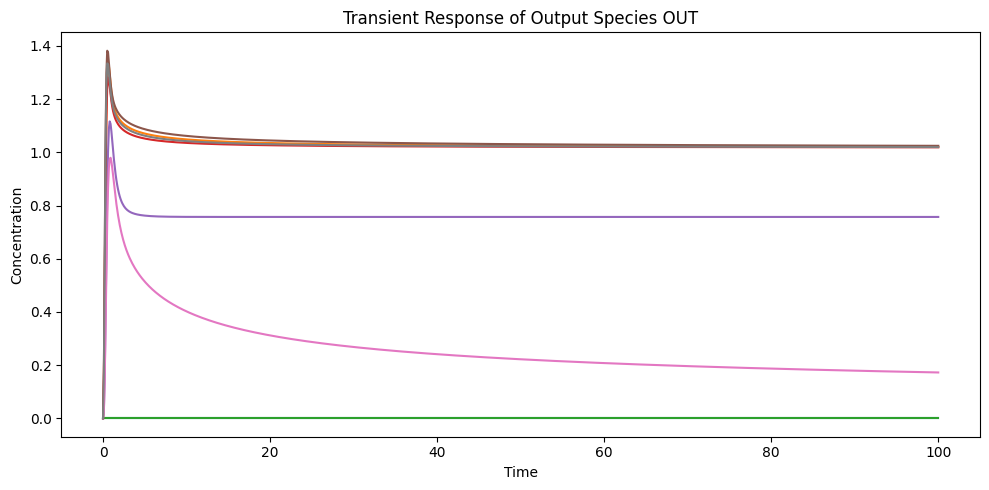

In [12]:
# Simulate Dynamics
iocrn.reset()
time_horizon = np.linspace(0, 100.0, 1000, dtype=np.float32)
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)


# Plot using class method
fig, ax = iocrn.plot_transient_response(alpha = 1)

In [ ]:
# # Construct the weights for the performance metric
# N_t = 1000
# w = np.zeros(N_t)
# w[(len(w)//5)*4:] = w[(len(w)//5)*4:] + 1
# w[:(len(w)//5)] = w[:(len(w)//5)]*0
# w = w[np.newaxis, :]

# # Compute Reward
# def compute_reward(state):
#    r_list = [np.array([u[0]]) for u in u_list]
#    print(r_list)
#    x0_list = ic.get_ic(state)
#    out = dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)
#    return out

# print(compute_reward(iocrn))

Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 ----> OUT + X_3;  [MAK(3.191404104232788)]
X_3 ----> OUT + X_3;  [MAK(30.425180435180664)]
X_1 + X_1 ----> X_1 + X_2;  [MAK(16.13312339782715)]
X_1 + X_1 ----> OUT + X_3;  [MAK(2.537935733795166)]
X_1 + X_2 ----> ∅;  [MAK(3.9893221855163574)]
X_1 + X_2 ----> X_2;  [MAK(9.542977333068848)]
OUT + X_3 ----> X_2 + X_2;  [MAK(5.8838958740234375)]
OUT + OUT ----> OUT + X_1;  [MAK(3.953247547149658)]


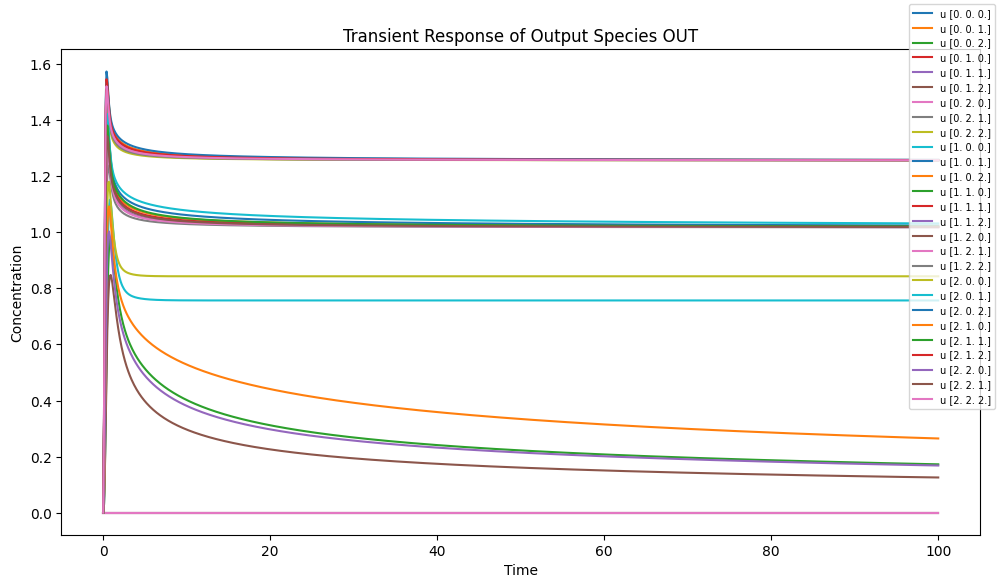

In [13]:
iocrn.reactions[0].set_parameters([1.])
iocrn.reset()
print(iocrn)
nums = np.linspace(0.0, 2.0, 3)
u_list = [np.array(u) for u in product(nums, repeat=num_inputs)]
t, x_list, y_list, task_info = iocrn.transient_response(u_list, x0_list, time_horizon)
fig, ax = iocrn.plot_transient_response(alpha = 1)
# use only 2 decimal places in legend
fig.legend([f"u {u}" for u in u_list], fontsize=7)
# size 
fig.set_size_inches(10, 6)


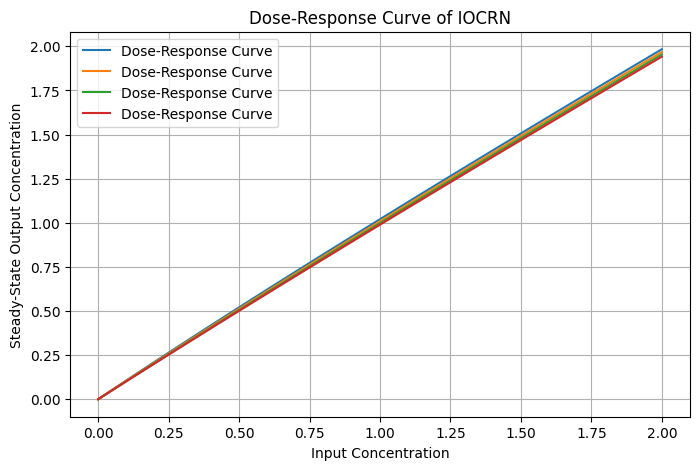

In [ ]:
# plot dose-response curve

import matplotlib.pyplot as plt
inputs = np.linspace(0, 2, 100)
steady_state_outputs = []

iocrn.reactions[0].set_parameters([1.])

for inp in inputs:
    iocrn.reset() 
    input_ = [inp]
    distrubance = [0.0, 0.5, 1.0, 1.5]
    # product
    u = [np.array(u) for u in product(input_, distrubance)]

    t, x, y, task_info = iocrn.transient_response(u, x0_list, np.linspace(0, 50, 10000))
    steady_state_outputs.append(np.array(y)[:, -1, -1]) 
    iocrn.reset()  
    
plt.figure(figsize=(8, 5))
plt.plot(inputs, steady_state_outputs, label='Dose-Response Curve')
plt.xlabel('Input Concentration')
plt.ylabel('Steady-State Output Concentration')
plt.title('Dose-Response Curve of IOCRN')
plt.legend()
plt.grid()
plt.show()
# save figure
# plt.savefig('dose_response_curve.png', dpi=300)

Simulating Dose-Response (50 steps x 5 disturbances)...


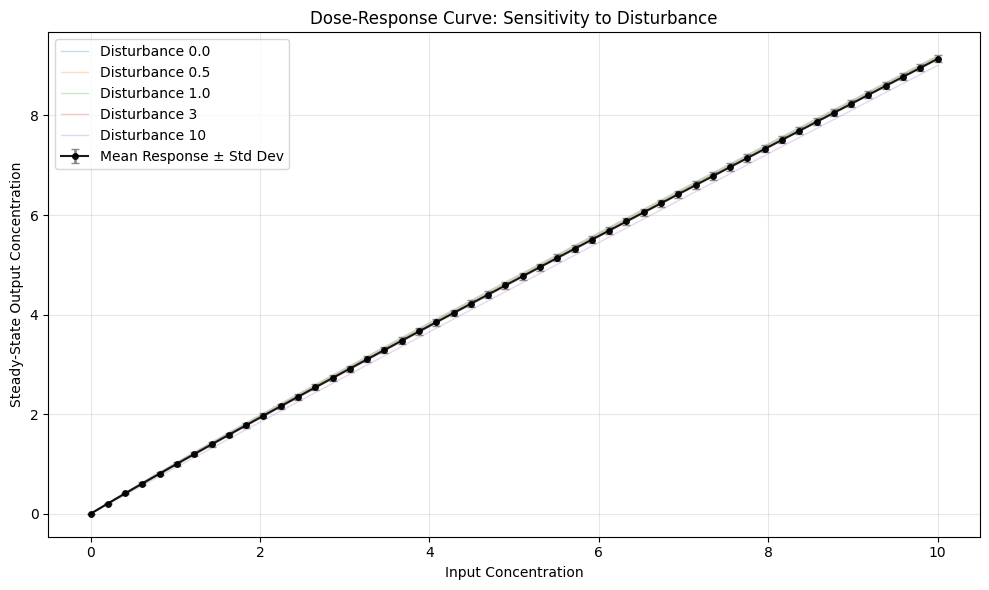

(array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
         1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
         2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
         3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
         4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
         5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
         6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
         7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
         8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
         9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ]),
 array([[0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.21604293, 0.21198755, 0.20876394, 0.20041023, 0.18934373],
        [0.42717494, 0.42015742, 0.41445853, 0.39924706, 0.37826808],
        [0.63447857, 0.6252307 , 0.61759123, 0.59668461, 0

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import product

def plot_dose_response_with_error(iocrn, x0_list, inputs, disturbances, t_span):
    """
    Plots a dose-response curve with error bars representing sensitivity to disturbances.
    
    Args:
        iocrn: The IOCRN object to simulate.
        x0_list: Initial conditions for the simulation.
        inputs: Array of input values to test (x-axis). Defaults to linspace(0, 2, 100).
        t_span: Time horizon for simulation. Defaults to linspace(0, 50, 10000).
    """
    
    # List to store the steady-state results for every input level
    # Shape will eventually be (num_inputs, num_disturbances)
    steady_state_matrix = []

    # Set parameter for the first reaction (as per original snippet)
    iocrn.reactions[0].set_parameters([1.])

    print(f"Simulating Dose-Response ({len(inputs)} steps x {len(disturbances)} disturbances)...")

    for inp in inputs:
        iocrn.reset() 
        
        # Create a batch of inputs for the current input level
        # We combine the single 'inp' with every 'disturbance' level
        # u_batch becomes: [[inp, 0.0], [inp, 0.5], [inp, 1.0], [inp, 1.5]]
        u_batch = [np.array([inp, d]) for d in disturbances]

        # Run transient response for the entire batch
        # y shape is typically (num_scenarios, num_time_steps, num_species)
        t, x, y, task_info = iocrn.transient_response(u_batch, x0_list, t_span)
        
        # Extract steady state: Take the last time step (-1) of the output species (-1)
        # This gives us a vector of size (num_disturbances,)
        ss_values = np.array(y)[:, -1, -1] 
        steady_state_matrix.append(ss_values)
        
        iocrn.reset()  
    
    # Convert list to numpy array for easy statistics
    # Shape: (N_inputs, N_disturbances)
    results = np.array(steady_state_matrix)

    # Calculate Mean and Standard Deviation across the disturbance dimension (axis 1)
    means = np.mean(results, axis=1)
    stds = np.std(results, axis=1)

    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    
    # 1. Plot individual trajectories with transparency
    # We iterate over columns to plot one line per disturbance level
    for i, d in enumerate(disturbances):
        plt.plot(inputs, results[:, i], 
                 marker='', linestyle='-', alpha=0.25, linewidth=1, 
                 label=f'Disturbance {d}')

    # 2. Plot the Mean curve with Error Bars
    plt.errorbar(inputs, means, yerr=stds, 
                 fmt='-o', color='black', ecolor='gray', 
                 elinewidth=2, capsize=3, markersize=4, alpha=0.9,
                 label='Mean Response ± Std Dev')

    plt.xlabel('Input Concentration')
    plt.ylabel('Steady-State Output Concentration')
    plt.title('Dose-Response Curve: Sensitivity to Disturbance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Optional: return the data if needed for further analysis
    return inputs, results


plot_dose_response_with_error(iocrn, x0_list, 
                             inputs=np.linspace(0, 10, 50), 
                             disturbances=[0.0, 0.5, 1.0, 3, 10],
                             t_span=np.linspace(0, 100, 5000))